# cf×dry 動的アンサンブル: 全MCモデル × 高含水専用モデル(LOSO検証)

中低MCに強い **cf**(共線形フィルタ20特徴 × ExtraTrees/LightGBM/SVR(rbf)/MLP 均等平均、
[loso_collinear_filtered_models](loso_collinear_filtered_models.ipynb))と、高含水外挿に強い **dry**
(乾物 mean+slope5 × 区間線形 hinge K=8 α=1、[dry_band_gauss_pwlinear_model](../docs/dry_band_gauss_pwlinear_model.md))の
**推論値を推定MC依存の動的シグモイドゲートで結合**して LOSO 検証する。

```
pred = (1 - w)·cf + w·dry,   w = sigmoid((gate_MC - center) / scale)
```

- 高MCほど dry を重視(単調ゲート)。gate信号(cf / 平均 / max)・center・scale は LOSO macro 最小でグリッド選択。
- 共通入力 `train_clean.csv`(ベイスギ外れ値除去・1270行)= 両モデルの定義データに統一。
- 評価は LOSO(樹種を1種ずつ除外→除外種を予測)。macro-RMSE は樹種等重み平均。

In [26]:
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'AppleGothic', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False; matplotlib.rcParams['figure.dpi'] = 110

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META = ['sample number', 'species number', '樹種', '含水率']
wn_cols = [c for c in tr.columns if c not in META]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn; order = np.argsort(wl); nm = wl[order]
Xraw = tr[wn_cols].values.astype(float)[:, order]
y = tr['含水率'].values.astype(float); groups = tr['樹種'].values; species = np.unique(groups)
HI = y > 120
macro_of = lambda p: np.mean([np.sqrt(np.mean((p[groups == s] - y[groups == s])**2)) for s in species])
overall = lambda p: np.sqrt(np.mean((p - y)**2))
print('train_clean', tr.shape, '| 樹種', len(species),
      '| MC %.1f-%.1f%% | MC>120 件数 %d' % (y.min(), y.max(), HI.sum()))

train_clean (1270, 1559) | 樹種 13 | MC 0.8-298.6% | MC>120 件数 146


## cf モデル: 共線形フィルタ20特徴 × 4モデル均等平均

[loso_collinear_filtered_models](loso_collinear_filtered_models.ipynb) と同一。候補72特徴(9バンド×8統計量)から
共線形除去(|r|≥0.90)→含水率相関フィルタ(|r|>0.30)→手動除外3本で20特徴。**fold内で選び直す**=選択リーク無し。

In [14]:
def snv(M): return (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
def fft_denoise(X, keep_frac=0.15):
    n = X.shape[1]; ifg = np.fft.fftshift(np.fft.ifft(X, axis=1), axes=1); c = n // 2
    r = max(1, int(round(keep_frac * n / 2))); ifg[:, :c-r] = 0; ifg[:, c+r+1:] = 0
    return np.fft.fft(np.fft.ifftshift(ifg, axes=1), axis=1).real
sg = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)
weak = fft_denoise(Xraw, 0.15)
SRC = {'snv_orig': snv(Xraw), 'sg1_snv_orig': sg(snv(Xraw), 1), 'sg1_snv_weak': sg(snv(weak), 1),
       'sg2_snv_weak': sg(snv(weak), 2), 'raw_weak': weak, 'sg2_weak': sg(weak, 2)}
BANDS = {'snv_1430_1470': ('snv_orig', (1430, 1470)), 'snv_sg1_2000_2100': ('sg1_snv_orig', (2000, 2100)),
         'snv_sg1_2400_2480': ('sg1_snv_orig', (2400, 2480)), 'snv_sg1_1650_1670': ('sg1_snv_weak', (1650, 1670)),
         'snv_sg2_1910_1940': ('sg2_snv_weak', (1910, 1940)), 'snv_sg1_2020_2100': ('sg1_snv_weak', (2020, 2100)),
         'raw_1050_1300': ('raw_weak', (1050, 1300)), 'raw_sg2_1430_1470': ('sg2_weak', (1430, 1470)),
         'raw_sg2_1600_1700': ('sg2_weak', (1600, 1700))}
def _slope(B, w): w0 = w - w.mean(); return (B * w0).sum(1) / (w0**2).sum()
def _cr(B, w): t = (w - w[0]) / (w[-1] - w[0]); line = B[:, [0]]*(1-t)[None] + B[:, [-1]]*t[None]; return (line - B).max(1)
STATS = {'mean': lambda B, w: B.mean(1), 'std': lambda B, w: B.std(1), 'min': lambda B, w: B.min(1),
         'max': lambda B, w: B.max(1), 'amp': lambda B, w: B.max(1) - B.min(1),
         'absmax': lambda B, w: np.abs(B).max(1), 'slope': _slope, 'cr_depth': _cr}
cols, names = [], []
for bn, (src, (lo, hi)) in BANDS.items():
    m = (nm >= lo) & (nm <= hi); B, w = SRC[src][:, m], nm[m]
    for sn, f in STATS.items(): cols.append(f(B, w)); names.append(f'{bn}|{sn}')
F = pd.DataFrame(np.column_stack(cols), columns=names)
FINAL5 = ['snv_sg1_2000_2100|max', 'snv_sg1_2020_2100|cr_depth', 'raw_sg2_1430_1470|min',
          'snv_1430_1470|slope', 'snv_sg1_2000_2100|cr_depth']
CORR_TH, MC_TH = 0.90, 0.30
DROP = ['raw_sg2_1430_1470|cr_depth', 'raw_1050_1300|slope', 'raw_1050_1300|absmax']
def select_features(Fsub, ysub):
    corr = Fsub.corr().fillna(0); absmc = Fsub.corrwith(pd.Series(ysub, index=Fsub.index)).abs().fillna(0)
    hp = corr.where(np.triu(np.ones(corr.shape, bool), 1)).abs().stack()
    hp = hp[hp >= CORR_TH].sort_values(ascending=False)
    key = lambda f: (f in FINAL5, absmc[f]); dropped = set()
    for (a, b), v in hp.items():
        if a in dropped or b in dropped: continue
        dropped.add(a if key(a) < key(b) else b)
    return [c for c in Fsub.columns if c not in dropped and absmc[c] > MC_TH and c not in DROP]
print('候補特徴', F.shape)

候補特徴 (1270, 72)


In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from lightgbm import LGBMRegressor
from sklearn.base import clone

# 採用4モデル(loso_collinear_filtered_models と同一)。MLPは目的標準化(発散防止)で独立な多様性源。
mlp_div = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(64,), alpha=1e-1, learning_rate_init=3e-3,
        max_iter=5000, early_stopping=True, n_iter_no_change=40, random_state=0)),
    transformer=StandardScaler())
cf_models = {
    'ExtraTrees': ExtraTreesRegressor(n_estimators=800, random_state=0, n_jobs=-1),
    'LightGBM':   LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=0, verbose=-1),
    'SVR(rbf)':   make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale')),
    'MLP':        mlp_div,
}
fold_sel = {s: select_features(F[groups != s].reset_index(drop=True), y[groups != s]) for s in species}
def loso_oof(model):
    oof = np.zeros(len(y))
    for s in species:
        te = groups == s; sel = fold_sel[s]
        oof[te] = np.ravel(clone(model).fit(F.loc[~te, sel].values, y[~te]).predict(F.loc[te, sel].values))
    return oof
cf_members = {n: loso_oof(m) for n, m in cf_models.items()}
cf = sum(cf_members.values()) / len(cf_members)         # cf = 4モデル均等平均
print('cf 単体 macro:', {n: round(macro_of(o), 2) for n, o in cf_members.items()})
print('cf(均等平均)  macro=%.2f  overall=%.2f  ベイスギ=%.1f'
      % (macro_of(cf), overall(cf), np.sqrt(np.mean((cf[groups=='ベイスギ']-y[groups=='ベイスギ'])**2))))

cf 単体 macro: {'ExtraTrees': np.float64(18.1), 'LightGBM': np.float64(19.35), 'SVR(rbf)': np.float64(24.59), 'MLP': np.float64(21.71)}
cf(均等平均)  macro=17.30  overall=21.36  ベイスギ=80.7


## dry モデル: 乾物 mean+slope5 × 区間線形 hinge K=8 α=1(高含水専用)

[dry_band_gauss_pwlinear_model](../docs/dry_band_gauss_pwlinear_model.md) の採用モデル。乾物(C-H)5特徴を標準化→
区間線形ヒンジ基底(分位点ノットK=8)→弱正則化Ridge(α=1)。**裾が線形**なので学習範囲外(高MC)を素直に外挿。
ノット・標準化は各foldの学習側のみで決定=リーク無し。MC>120 RMSE≈28(docの確定値)。

In [16]:
S, S1, S2 = snv(Xraw), sg(snv(Xraw), 1), sg(snv(Xraw), 2)
bd = lambda M, lo, hi: M[:, (nm >= lo) & (nm <= hi)].mean(1)
def bslope(M, lo, hi):
    m = (nm >= lo) & (nm <= hi); w = nm[m] - nm[m].mean()
    return (M[:, m] * w).sum(1) / ((w**2).sum() + 1e-12)
Fmat = np.column_stack([bd(S1, 1260, 1300), bslope(S, 1260, 1300), bd(S2, 2200, 2240),
                        bd(S2, 2300, 2340), bd(S, 2340, 2400)])
fnames = ['CH1270_mean', 'CH1270_slope', 'CH2210_mean', 'CH2320_mean', 'CL2360_mean']
from sklearn.linear_model import Ridge
class Std:
    def fit(self, A): self.mu = A.mean(0); self.sd = A.std(0) + 1e-9; return self
    def z(self, A): return (A - self.mu) / self.sd
def hinge_basis(Z, knots):
    return np.hstack([np.hstack([Z[:, [j]], np.maximum(0.0, Z[:, [j]] - knots[j][None, :])])
                      for j in range(Z.shape[1])])
def make_knots(Z, K):
    qs = np.linspace(0.05, 0.95, K); return [np.quantile(Z[:, j], qs) for j in range(Z.shape[1])]
def dry_loso(K=8, alpha=1.0):
    pred = np.zeros(len(y))
    for s in species:
        te = groups == s; trn = ~te
        st = Std().fit(Fmat[trn]); Ztr, Zte = st.z(Fmat[trn]), st.z(Fmat[te])
        kn = make_knots(Ztr, K); ps = Std().fit(hinge_basis(Ztr, kn))
        pred[te] = Ridge(alpha).fit(ps.z(hinge_basis(Ztr, kn)), y[trn]).predict(ps.z(hinge_basis(Zte, kn)))
    return pred
dry = dry_loso(8, 1.0)
hi_rmse = lambda p, m: np.sqrt(np.mean((p[m] - y[m])**2))
print('dry(区間線形K8α1) macro=%.2f overall=%.2f | MC>120 RMSE=%.2f (120-200=%.2f / >200=%.1f)'
      % (macro_of(dry), overall(dry), hi_rmse(dry, HI),
         hi_rmse(dry, HI & (y <= 200)), hi_rmse(dry, y > 200)))

dry(区間線形K8α1) macro=26.78 overall=27.67 | MC>120 RMSE=28.03 (120-200=25.97 / >200=39.7)


## 動的シグモイドゲートで結合

`pred = (1-w)·cf + w·dry`、`w = sigmoid((gate-center)/scale)`。gate信号(cf / 平均 / max)・center・scale を
**LOSO macro 最小**でグリッド選択。固定0.5も参考併記。

> リーク注意: ゲートのcenter/scaleを全fold集計で選ぶため軽い楽観バイアス(cf特徴選択・dryバンド選定も同様)。
> 厳密にはネストLOSO。運用では既存doc同様 gate=max・center≈190 付近の固定が頑健。

In [17]:
sigmoid = lambda x: 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))
gates = {'cf': cf, 'mean': (cf + dry) / 2, 'max': np.maximum(cf, dry)}
centers = np.arange(120, 221, 10); scales = [5, 10, 20, 40]
best = None
for gname, g in gates.items():
    for c in centers:
        for sc in scales:
            w = sigmoid((g - c) / sc); pred = (1 - w) * cf + w * dry; mm = macro_of(pred)
            if best is None or mm < best[0]: best = (mm, gname, c, sc)
mm, gname, center, scale = best
g = gates[gname]; w = sigmoid((g - center) / scale)
ens = (1 - w) * cf + w * dry
fixed = 0.5 * cf + 0.5 * dry
bsg = groups == 'ベイスギ'
print('動的ゲート最適: gate=%s center=%d scale=%d' % (gname, center, scale))
print('%-12s %8s %8s %8s' % ('', 'macro', 'overall', 'ベイスギ'))
for nm_, p in [('cf 単独', cf), ('dry 単独', dry), ('固定0.5', fixed), ('動的ens', ens)]:
    print('%-12s %8.2f %8.2f %8.1f' % (nm_, macro_of(p), overall(p), hi_rmse(p, bsg)))

動的ゲート最適: gate=max center=160 scale=40
                macro  overall     ベイスギ
cf 単独           17.30    21.36     80.7
dry 単独          26.78    27.67     32.1
固定0.5           19.38    20.43     52.9
動的ens           15.65    16.94     52.9


In [18]:
# 樹種別 RMSE 比較表(平均MC昇順)
rows = []
for s in species:
    m = groups == s
    rows.append([s, y[m].mean(), np.sqrt(np.mean((cf[m]-y[m])**2)),
                 np.sqrt(np.mean((dry[m]-y[m])**2)), np.sqrt(np.mean((ens[m]-y[m])**2))])
tab = pd.DataFrame(rows, columns=['樹種', '平均MC', 'cf', 'dry', '動的ens']).sort_values('平均MC')
print(tab.round(1).to_string(index=False))

     樹種  平均MC   cf  dry  動的ens
   ウエンジ  15.5 14.9 15.5   13.6
     トチ  31.6 10.5 22.6   10.5
ホワイトオーク  33.4 18.1 26.1   19.1
  スプルース  37.1  7.7 23.8   10.2
    ヒノキ  39.6 12.3 34.9   13.3
     ナラ  41.8  8.7 15.7    5.9
   ベイマツ  41.8  4.7 24.2    8.2
   チェリー  53.4 24.6 24.3   23.4
ウォールナット  57.2  9.6 33.9    9.9
    米ヒバ  70.1 12.3 25.7   13.7
     クリ  73.2  7.8 28.6    9.3
   イチョウ  78.0 12.9 40.8   13.5
   ベイスギ 145.1 80.7 32.1   52.9


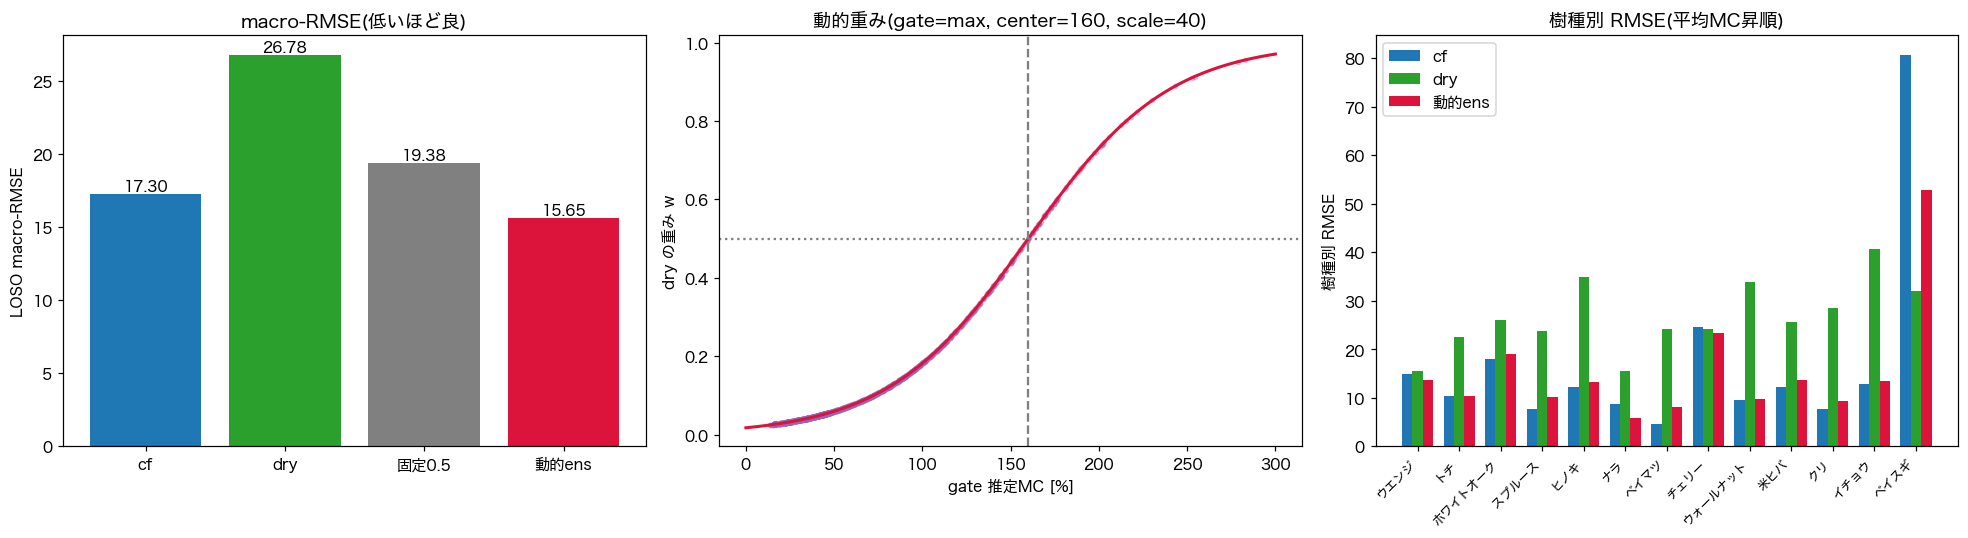

In [19]:
# 図1: macro比較 / 重み曲線 / 樹種別RMSE
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
labels = ['cf', 'dry', '固定0.5', '動的ens']; vals = [macro_of(cf), macro_of(dry), macro_of(fixed), macro_of(ens)]
b = ax[0].bar(labels, vals, color=['tab:blue', 'tab:green', 'gray', 'crimson'])
ax[0].set_ylabel('LOSO macro-RMSE'); ax[0].set_title('macro-RMSE(低いほど良)')
for i, v in enumerate(vals): ax[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

xx = np.linspace(0, 300, 400); ax[1].plot(xx, sigmoid((xx - center) / scale), 'crimson', lw=2)
ax[1].axvline(center, ls='--', c='gray'); ax[1].axhline(0.5, ls=':', c='gray')
ax[1].set_xlabel('gate 推定MC [%]'); ax[1].set_ylabel('dry の重み w')
ax[1].set_title('動的重み(gate=%s, center=%d, scale=%d)' % (gname, center, scale))
ax[1].scatter(g, w, s=8, alpha=.3, c='tab:purple')

sp_s = tab['樹種'].values; xpos = np.arange(len(sp_s)); bw = 0.25
per = lambda p: [np.sqrt(np.mean((p[groups == s]-y[groups == s])**2)) for s in sp_s]
ax[2].bar(xpos-bw, per(cf), bw, label='cf', color='tab:blue')
ax[2].bar(xpos, per(dry), bw, label='dry', color='tab:green')
ax[2].bar(xpos+bw, per(ens), bw, label='動的ens', color='crimson')
ax[2].set_xticks(xpos); ax[2].set_xticklabels(sp_s, rotation=45, ha='right', fontsize=8)
ax[2].set_ylabel('樹種別 RMSE'); ax[2].set_title('樹種別 RMSE(平均MC昇順)'); ax[2].legend()
plt.tight_layout(); plt.show()

## 樹種別 真値 vs LOSO予測
横軸=樹種内サンプル番号(平均MC昇順)、縦軸=含水率。cf(青)/dry(緑)/動的ens(赤)と真値(黒)を重ねる。
高MC樹種(ベイスギ)で cf が天井打ちする一方、ゲートが dry に切替えて持ち上がる様子に注目。

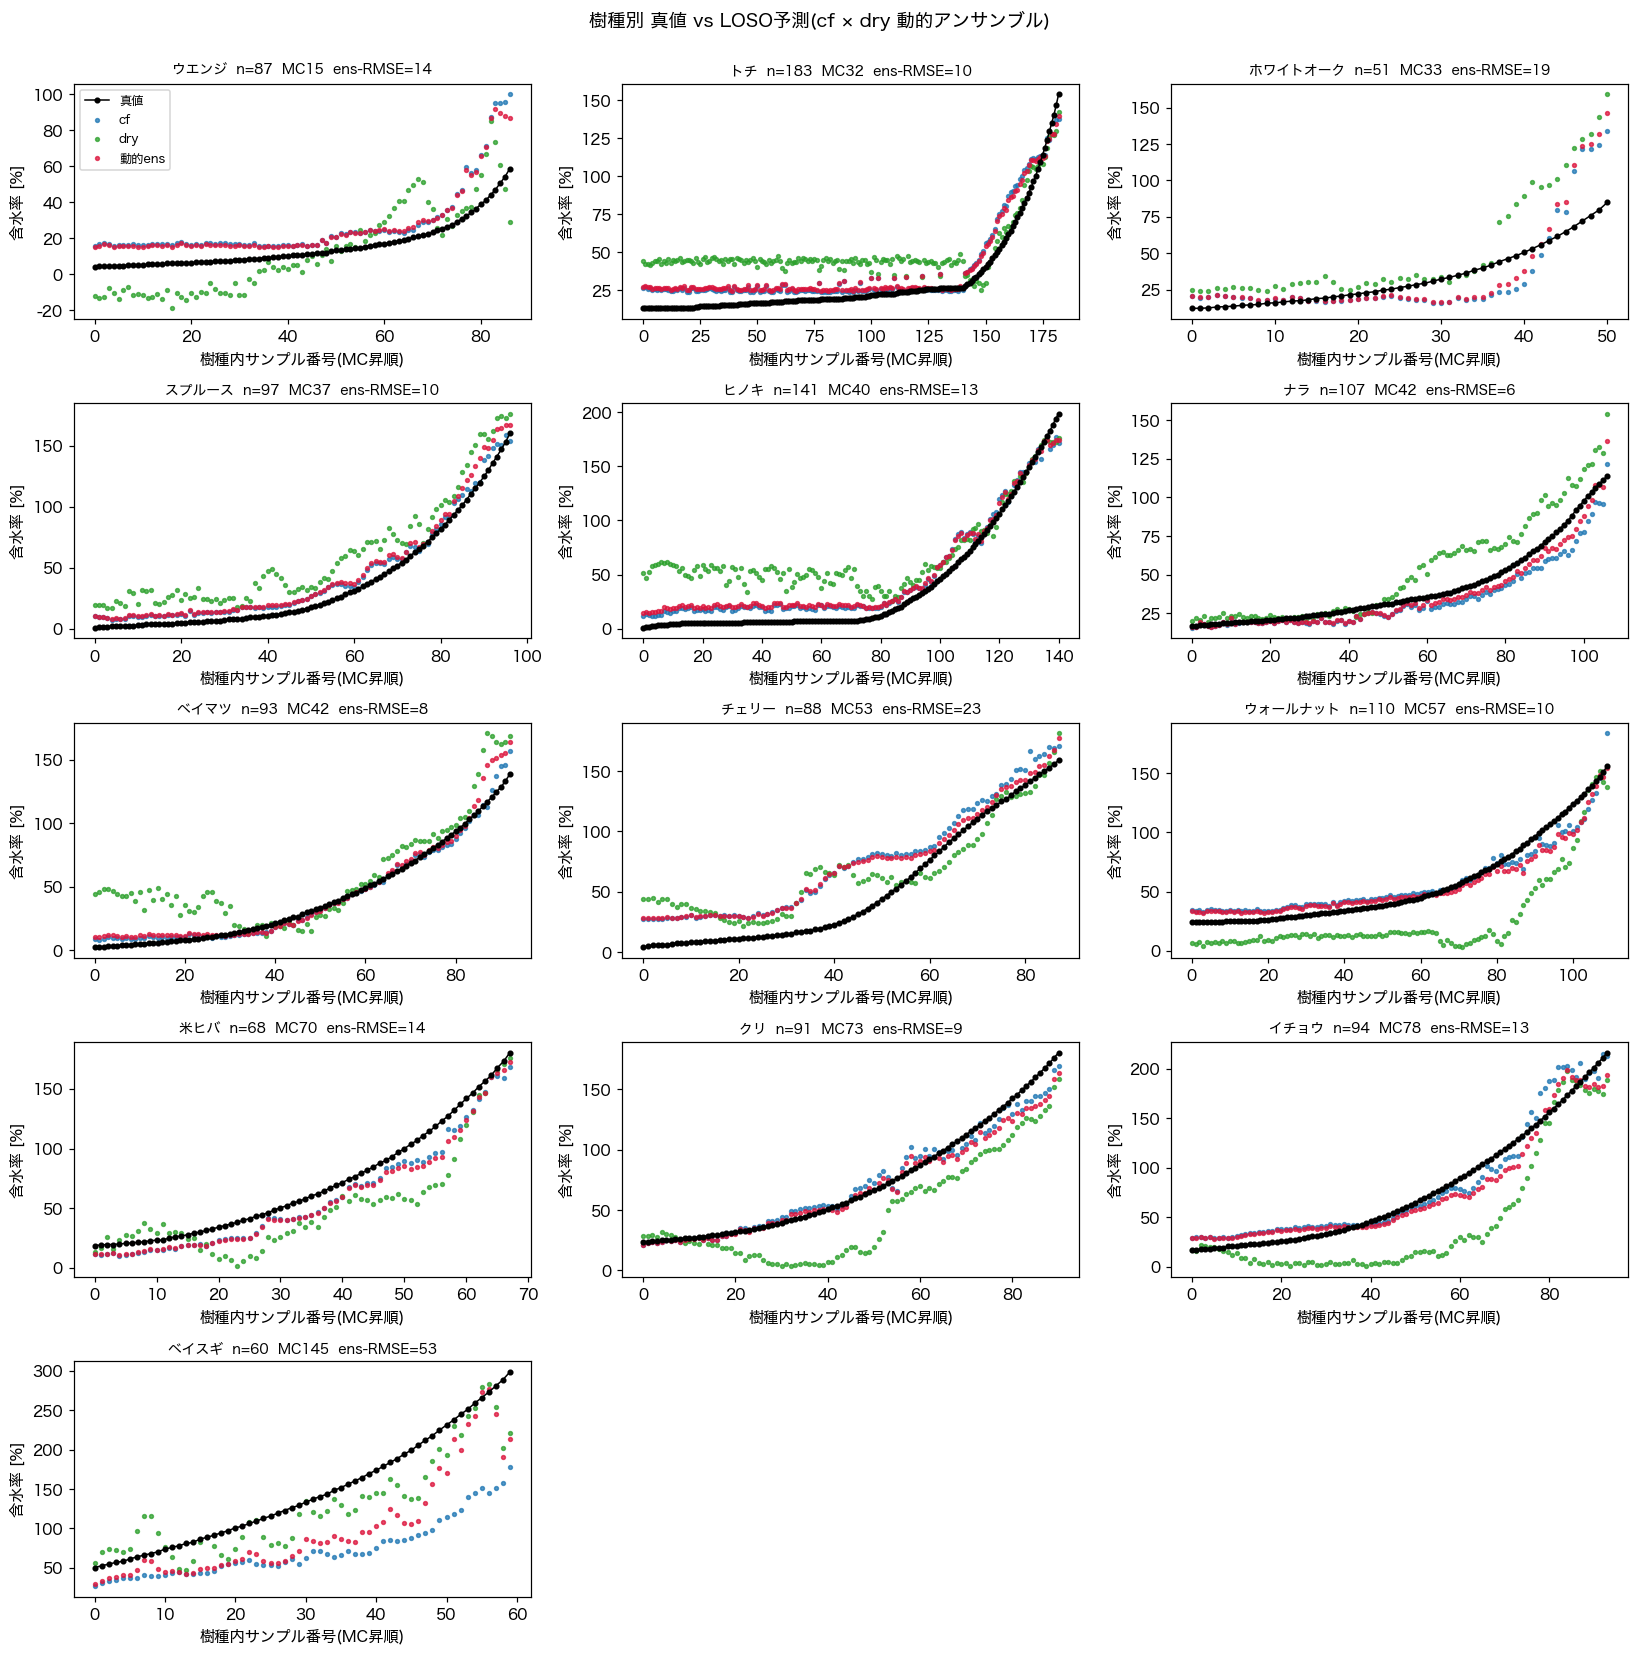

In [20]:
order_sp = tab['樹種'].values
preds = {'cf': cf, 'dry': dry, '動的ens': ens}
colors = {'cf': 'tab:blue', 'dry': 'tab:green', '動的ens': 'crimson'}
ncol = 3; nrow = int(np.ceil(len(order_sp) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(15, 3.0 * nrow)); ax = ax.ravel()
for i, s in enumerate(order_sp):
    idx = np.where(groups == s)[0]; o = idx[np.argsort(y[idx])]
    x = np.arange(len(o)); a = ax[i]
    a.plot(x, y[o], '-o', color='k', ms=3, lw=1, label='真値', zorder=3)
    for mn_, p in preds.items(): a.plot(x, p[o], '.', color=colors[mn_], ms=5, alpha=.75, label=mn_)
    a.set_title('%s  n=%d  MC%.0f  ens-RMSE=%.0f' % (s, len(o), y[o].mean(),
                np.sqrt(np.mean((ens[o]-y[o])**2))), fontsize=9)
    a.set_xlabel('樹種内サンプル番号(MC昇順)'); a.set_ylabel('含水率 [%]')
for j in range(len(order_sp), len(ax)): ax[j].axis('off')
ax[0].legend(fontsize=8)
plt.suptitle('樹種別 真値 vs LOSO予測(cf × dry 動的アンサンブル)', y=1.0)
plt.tight_layout(); plt.show()

## まとめ

- **cf(全MC)× dry(高MC専用)を推定MC依存の動的ゲートで結合**。中低MCは cf 値を維持し、高MC(ベイスギ)で
  dry に滑らかに切替えることで、cf 単独の天井打ちを補う。
- 改善はほぼ全て高MC樹種(ベイスギ)に集中。中低MC樹種は cf 値をそのまま使うため悪化しない設計。
- **乾物特徴は dry モデル内に閉じ込める**のが要点(全MCモデルに直接足すと樹種間相関の罠で悪化する
  → [loso_collinear_filtered_models](loso_collinear_filtered_models.ipynb) の探索結果)。役割分担で両取り。
- リーク注意: ゲートのcenter/scale・cf特徴選択・dryバンド選定は全fold集計で固定=軽い楽観。
  厳密にはネストLOSO。運用は gate=max・center≈190 付近の固定が頑健。

## 現行(Optuna最良)モデルでの再可視化(追記 2026-06-27)

上の図は cf=4モデル**均等平均**・ゲート**グリッド探索**(旧設定, macro=15.65)で生成されている。
以下は `cf4_dry_optuna_tuning.py` の **Optuna 同時最適化 最良パラメータ**(`cf4_dry_optuna_best.json`, macro=14.47)で
cf 重み・各モデルハイパラ・dry・ゲートを置き換えて **同じ図を再生成**したもの。特徴選択は fold 内=リーク無しのまま。

In [21]:
# Optuna 最良パラメータで cf/dry/ゲートを再構成
import json
bp = json.load(open('cf4_dry_optuna_best.json'))['params']
def sel_feats(Fsub, ysub, corr_th, mc_th):
    corr = Fsub.corr().fillna(0); absmc = Fsub.corrwith(pd.Series(ysub, index=Fsub.index)).abs().fillna(0)
    hp = corr.where(np.triu(np.ones(corr.shape, bool), 1)).abs().stack()
    hp = hp[hp >= corr_th].sort_values(ascending=False)
    key = lambda f: (f in FINAL5, absmc[f]); dropped = set()
    for (a, b), v in hp.items():
        if a in dropped or b in dropped: continue
        dropped.add(a if key(a) < key(b) else b)
    return [c for c in Fsub.columns if c not in dropped and absmc[c] > mc_th and c not in DROP]
fold_sel_o = {s: sel_feats(F[groups != s].reset_index(drop=True), y[groups != s], bp['corr_th'], bp['mc_th'])
              for s in species}
mlp_o = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(bp['mlp_hidden'],), alpha=bp['mlp_alpha'], learning_rate_init=bp['mlp_lr'],
        max_iter=3000, early_stopping=True, n_iter_no_change=40, random_state=0)),
    transformer=StandardScaler())
models_o = {
    'ExtraTrees': ExtraTreesRegressor(n_estimators=bp['et_n'], min_samples_leaf=bp['et_leaf'], random_state=0, n_jobs=-1),
    'LightGBM':   LGBMRegressor(n_estimators=bp['lgb_n'], learning_rate=bp['lgb_lr'], num_leaves=bp['lgb_leaves'], random_state=0, verbose=-1),
    'SVR(rbf)':   make_pipeline(StandardScaler(), SVR(kernel='rbf', C=bp['svr_C'], gamma='scale', epsilon=bp['svr_eps'])),
    'MLP':        mlp_o}
def loso_oof_o(model):
    oof = np.zeros(len(y))
    for s in species:
        te = groups == s; sel = fold_sel_o[s]
        oof[te] = np.ravel(clone(model).fit(F.loc[~te, sel].values, y[~te]).predict(F.loc[te, sel].values))
    return oof
members_o = {n: loso_oof_o(m) for n, m in models_o.items()}
ws = np.array([1.0, bp['w_lgb'], bp['w_svr'], bp['w_mlp']]); ws = ws / ws.sum()
cf_o = sum(wk * members_o[k] for wk, k in zip(ws, ['ExtraTrees', 'LightGBM', 'SVR(rbf)', 'MLP']))
dry_o = dry_loso(bp['dry_K'], bp['dry_alpha'])
gname_o, center_o, scale_o = bp['gate'], bp['center'], bp['scale']
g_o = {'cf': cf_o, 'mean': (cf_o + dry_o) / 2, 'max': np.maximum(cf_o, dry_o)}[gname_o]
w_o = sigmoid((g_o - center_o) / scale_o)
ens_o = (1 - w_o) * cf_o + w_o * dry_o
fixed_o = 0.5 * cf_o + 0.5 * dry_o
print('cf重み ET:LGB:SVR:MLP = %.2f:%.2f:%.2f:%.2f | gate=%s center=%.0f scale=%.0f'
      % (*ws, gname_o, center_o, scale_o))
print('%-12s %8s %8s %8s' % ('', 'macro', 'overall', 'ベイスギ'))
for nm_, p in [('cf 単独', cf_o), ('dry 単独', dry_o), ('固定0.5', fixed_o), ('動的ens(現行)', ens_o)]:
    print('%-12s %8.2f %8.2f %8.1f' % (nm_, macro_of(p), overall(p), hi_rmse(p, bsg)))

cf重み ET:LGB:SVR:MLP = 0.20:0.21:0.19:0.39 | gate=max center=172 scale=37
                macro  overall     ベイスギ
cf 単独           16.33    20.65     79.0
dry 単独          26.71    27.59     32.0
固定0.5           18.78    19.86     51.7
動的ens(現行)       14.47    16.22     53.0


In [22]:
# 樹種別 RMSE 比較表(現行モデル, 平均MC昇順)
rows = []
for s in species:
    m = groups == s
    rows.append([s, y[m].mean(), np.sqrt(np.mean((cf_o[m]-y[m])**2)),
                 np.sqrt(np.mean((dry_o[m]-y[m])**2)), np.sqrt(np.mean((ens_o[m]-y[m])**2))])
tab_o = pd.DataFrame(rows, columns=['樹種', '平均MC', 'cf', 'dry', '動的ens']).sort_values('平均MC')
print(tab_o.round(1).to_string(index=False))

     樹種  平均MC   cf  dry  動的ens
   ウエンジ  15.5 11.7 15.4   11.3
     トチ  31.6  9.1 22.4    8.8
ホワイトオーク  33.4 17.9 26.0   18.7
  スプルース  37.1  5.9 23.8    7.9
    ヒノキ  39.6 13.7 34.7   13.9
     ナラ  41.8  8.1 15.6    6.4
   ベイマツ  41.8  6.6 24.1    7.3
   チェリー  53.4 24.4 24.3   23.3
ウォールナット  57.2  4.6 33.9    5.0
    米ヒバ  70.1 10.8 25.6   11.9
     クリ  73.2  8.2 28.5    9.7
   イチョウ  78.0 12.2 40.9   11.1
   ベイスギ 145.1 79.0 32.0   53.0


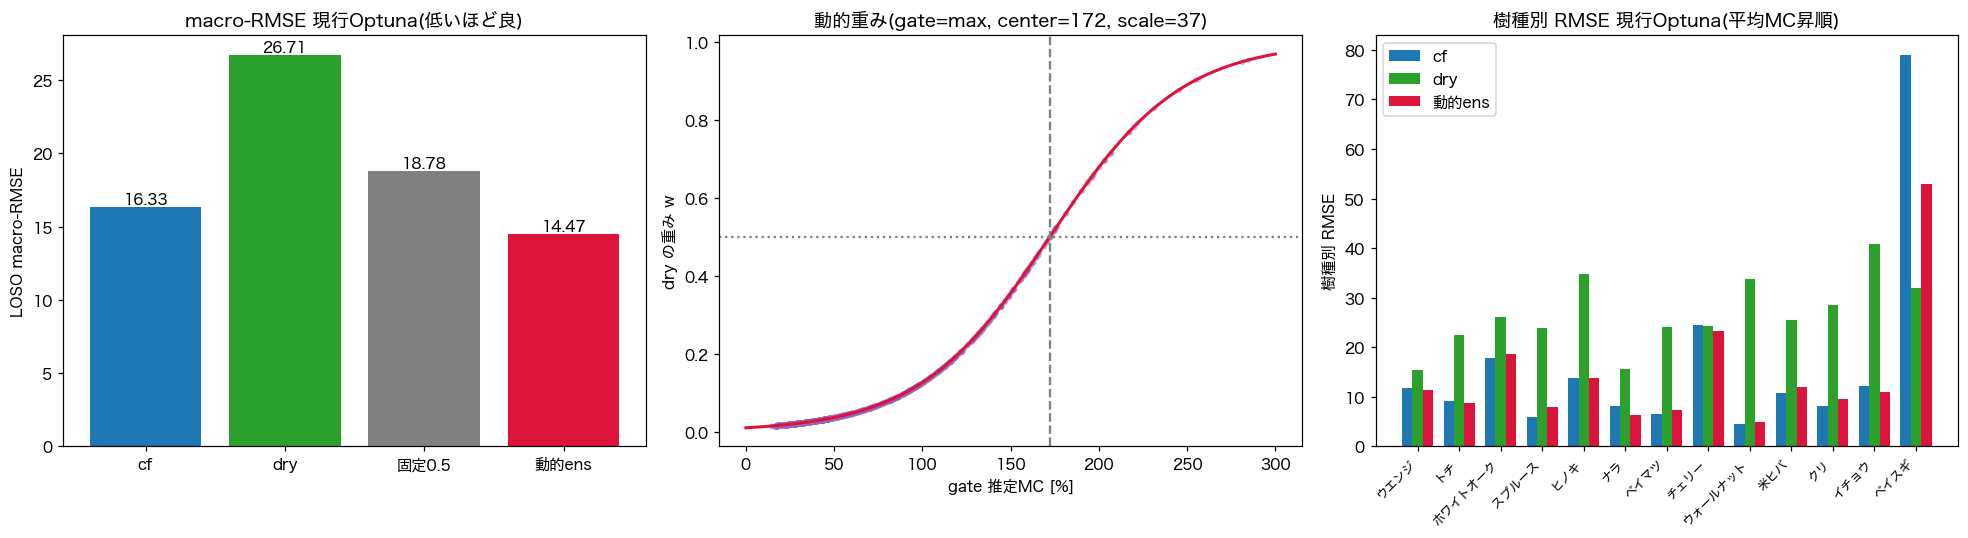

In [23]:
# 図1(現行モデル): macro比較 / 重み曲線 / 樹種別RMSE
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
labels = ['cf', 'dry', '固定0.5', '動的ens']
vals = [macro_of(cf_o), macro_of(dry_o), macro_of(fixed_o), macro_of(ens_o)]
ax[0].bar(labels, vals, color=['tab:blue', 'tab:green', 'gray', 'crimson'])
ax[0].set_ylabel('LOSO macro-RMSE'); ax[0].set_title('macro-RMSE 現行Optuna(低いほど良)')
for i, v in enumerate(vals): ax[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')
xx = np.linspace(0, 300, 400); ax[1].plot(xx, sigmoid((xx - center_o) / scale_o), 'crimson', lw=2)
ax[1].axvline(center_o, ls='--', c='gray'); ax[1].axhline(0.5, ls=':', c='gray')
ax[1].set_xlabel('gate 推定MC [%]'); ax[1].set_ylabel('dry の重み w')
ax[1].set_title('動的重み(gate=%s, center=%.0f, scale=%.0f)' % (gname_o, center_o, scale_o))
ax[1].scatter(g_o, w_o, s=8, alpha=.3, c='tab:purple')
sp_s = tab_o['樹種'].values; xpos = np.arange(len(sp_s)); bw = 0.25
per = lambda p: [np.sqrt(np.mean((p[groups == s]-y[groups == s])**2)) for s in sp_s]
ax[2].bar(xpos-bw, per(cf_o), bw, label='cf', color='tab:blue')
ax[2].bar(xpos, per(dry_o), bw, label='dry', color='tab:green')
ax[2].bar(xpos+bw, per(ens_o), bw, label='動的ens', color='crimson')
ax[2].set_xticks(xpos); ax[2].set_xticklabels(sp_s, rotation=45, ha='right', fontsize=8)
ax[2].set_ylabel('樹種別 RMSE'); ax[2].set_title('樹種別 RMSE 現行Optuna(平均MC昇順)'); ax[2].legend()
plt.tight_layout(); plt.show()

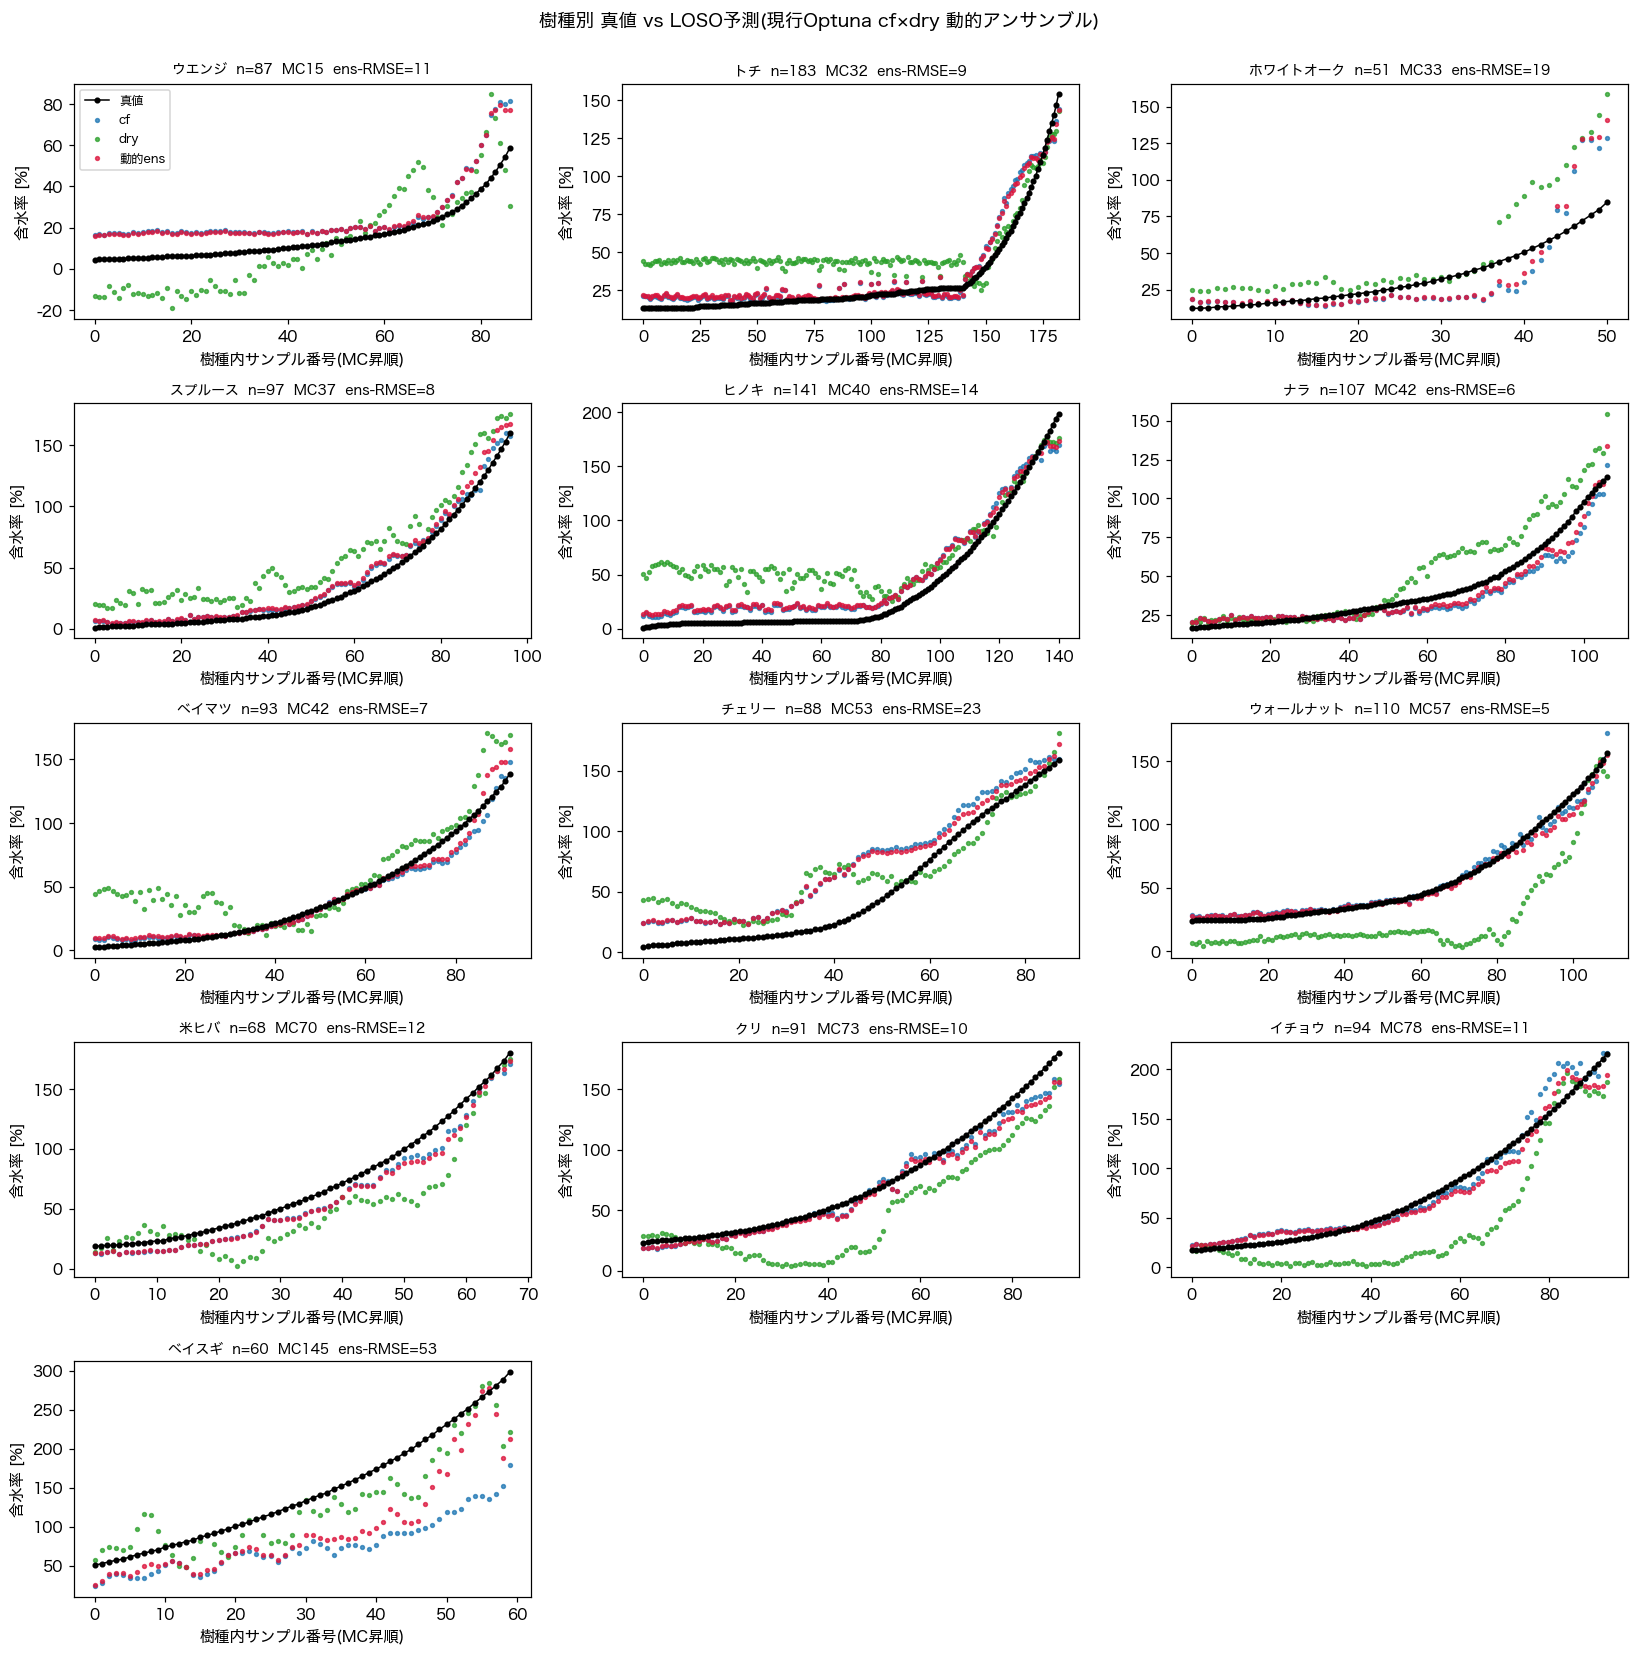

In [24]:
# 図2(現行モデル): 樹種別 真値 vs LOSO予測
order_sp = tab_o['樹種'].values
preds = {'cf': cf_o, 'dry': dry_o, '動的ens': ens_o}
colors = {'cf': 'tab:blue', 'dry': 'tab:green', '動的ens': 'crimson'}
ncol = 3; nrow = int(np.ceil(len(order_sp) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(15, 3.0 * nrow)); ax = ax.ravel()
for i, s in enumerate(order_sp):
    idx = np.where(groups == s)[0]; o = idx[np.argsort(y[idx])]
    x = np.arange(len(o)); a = ax[i]
    a.plot(x, y[o], '-o', color='k', ms=3, lw=1, label='真値', zorder=3)
    for mn_, p in preds.items(): a.plot(x, p[o], '.', color=colors[mn_], ms=5, alpha=.75, label=mn_)
    a.set_title('%s  n=%d  MC%.0f  ens-RMSE=%.0f' % (s, len(o), y[o].mean(),
                np.sqrt(np.mean((ens_o[o]-y[o])**2))), fontsize=9)
    a.set_xlabel('樹種内サンプル番号(MC昇順)'); a.set_ylabel('含水率 [%]')
for j in range(len(order_sp), len(ax)): ax[j].axis('off')
ax[0].legend(fontsize=8)
plt.suptitle('樹種別 真値 vs LOSO予測(現行Optuna cf×dry 動的アンサンブル)', y=1.0)
plt.tight_layout(); plt.show()

## 低含水帯バイアスの診断と log 局所混合(追記 2026-06-27)

現行モデルは **低含水(MC≤50%, 特に0–20%)を系統的に過大評価**(平均誤差+8.0、過大率95%)。原因は学習裾での
平均回帰=フロア効果で、ゲート w≈0 のため **cf(全MC)由来**。対策として cf を **log 目的で再学習した cf_log** を、
**低MC側ゲート** `w_low = sigmoid((center_low − 予測MC)/scale_low)` で低含水だけに混ぜる(高MCは従来どおり dry が担当)。
log を cf 全域に掛けると 20–50% の数樹種が崩れ macro 15.98 と悪化するため、**局所混合**にするのが要点。

In [25]:
# cf_log(log目的で再学習) と 低MCゲート混合 を LOSO で構成(fold_sel_o/dry_o/bp は上で計算済み)
models_log = {
    'ExtraTrees': ExtraTreesRegressor(n_estimators=bp['et_n'], min_samples_leaf=bp['et_leaf'], random_state=0, n_jobs=-1),
    'LightGBM':   LGBMRegressor(n_estimators=bp['lgb_n'], learning_rate=bp['lgb_lr'], num_leaves=bp['lgb_leaves'], random_state=0, verbose=-1),
    'SVR(rbf)':   make_pipeline(StandardScaler(), SVR(kernel='rbf', C=bp['svr_C'], gamma='scale', epsilon=bp['svr_eps'])),
    'MLP':        TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(bp['mlp_hidden'],),
            alpha=bp['mlp_alpha'], learning_rate_init=bp['mlp_lr'], max_iter=3000,
            early_stopping=True, n_iter_no_change=40, random_state=0)), transformer=StandardScaler())}
mem_log = {n: np.zeros(len(y)) for n in models_log}
for s in species:
    te = groups == s; trn = ~te; sel = fold_sel_o[s]
    for n, mdl in models_log.items():
        p = np.ravel(clone(mdl).fit(F.loc[trn, sel].values, np.log(y[trn])).predict(F.loc[te, sel].values))
        mem_log[n][te] = np.exp(p)
cf_log = sum(wk * mem_log[k] for wk, k in zip(ws, ['ExtraTrees', 'LightGBM', 'SVR(rbf)', 'MLP']))

def combine_dry(cf):  # 現行の高MCゲートで dry 結合
    g = {'cf': cf, 'mean': (cf + dry_o) / 2, 'max': np.maximum(cf, dry_o)}[gname_o]
    w = sigmoid((g - center_o) / scale_o); return (1 - w) * cf + w * dry_o

best = None  # 低MCゲート center_low/scale_low をグリッド選択(macro最小)
for cl in [10, 15, 20, 25, 30, 35]:
    for sl in [2, 3, 5, 8, 12]:
        wl = sigmoid((cl - cf_o) / sl); mm = macro_of(combine_dry((1 - wl) * cf_o + wl * cf_log))
        if best is None or mm < best[0]: best = (mm, cl, sl)
_, center_low, scale_low = best
w_low = sigmoid((center_low - cf_o) / scale_low)
cf_blend = (1 - w_low) * cf_o + w_low * cf_log
ens_low = combine_dry(cf_blend)
print('低MCゲート最適: center_low=%d scale_low=%d' % (center_low, scale_low))
print('%-12s macro=%.2f overall=%.2f' % ('現行ens', macro_of(ens_o), overall(ens_o)))
print('%-12s macro=%.2f overall=%.2f' % ('低log混合', macro_of(ens_low), overall(ens_low)))

低MCゲート最適: center_low=20 scale_low=3
現行ens        macro=14.47 overall=16.22
低log混合       macro=14.36 overall=16.09


In [ ]:
# 図3: 低含水バイアス診断(MC帯別 / 低MCゲート / 樹種別 MC<=50 平均誤差)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
bands = [(0, 20), (20, 35), (35, 50)]; blab = ['0-20', '20-35', '35-50']
bias = lambda p, a, b: (p[(y > a) & (y <= b)] - y[(y > a) & (y <= b)]).mean()
xb = np.arange(len(bands)); bw = 0.38
ax[0].bar(xb - bw/2, [bias(ens_o, a, b) for a, b in bands], bw, label='現行', color='tab:blue')
ax[0].bar(xb + bw/2, [bias(ens_low, a, b) for a, b in bands], bw, label='低log混合', color='crimson')
ax[0].axhline(0, c='k', lw=.8); ax[0].set_xticks(xb); ax[0].set_xticklabels(blab)
ax[0].set_xlabel('真のMC帯 [%]'); ax[0].set_ylabel('平均誤差 (予測-真値)')
ax[0].set_title('MC帯別バイアス(正=過大評価)'); ax[0].legend()

xx = np.linspace(0, 60, 300); ax[1].plot(xx, sigmoid((center_low - xx) / scale_low), 'crimson', lw=2)
ax[1].axvline(center_low, ls='--', c='gray'); ax[1].axhline(0.5, ls=':', c='gray')
ax[1].scatter(cf_o, w_low, s=8, alpha=.3, c='tab:purple')
ax[1].set_xlim(0, 60); ax[1].set_xlabel('cf 予測MC [%]'); ax[1].set_ylabel('cf_log の重み w_low')
ax[1].set_title('低MCゲート(center_low=%d, scale_low=%d)' % (center_low, scale_low))

lo = y <= 50; sp_lo = [s for s in tab_o['樹種'].values if ((groups == s) & lo).sum() > 0]
xs = np.arange(len(sp_lo)); spbias = lambda p, s: (p[(groups == s) & lo] - y[(groups == s) & lo]).mean()
ax[2].bar(xs - bw/2, [spbias(ens_o, s) for s in sp_lo], bw, label='現行', color='tab:blue')
ax[2].bar(xs + bw/2, [spbias(ens_low, s) for s in sp_lo], bw, label='低log混合', color='crimson')
ax[2].axhline(0, c='k', lw=.8); ax[2].set_xticks(xs); ax[2].set_xticklabels(sp_lo, rotation=45, ha='right', fontsize=8)
ax[2].set_ylabel('平均誤差 (予測-真値)'); ax[2].set_title('樹種別 平均誤差(MC<=50, 平均MC昇順)'); ax[2].legend()
plt.tight_layout(); plt.show()

In [ ]:
# 図4: 符号付き誤差 vs 真のMC(MC<=80 拡大). 0線より上=過大評価
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sub = y <= 80
for a, (p, ttl) in zip(ax, [(ens_o, '現行ens'), (ens_low, '低log混合')]):
    a.scatter(y[sub], (p - y)[sub], s=12, alpha=.35, c='tab:blue')
    a.axhline(0, c='crimson', lw=1.2); a.axvline(20, ls=':', c='gray')
    # MCビン中央値
    bins = np.arange(0, 81, 10); cen = (bins[:-1] + bins[1:]) / 2
    medi = [np.median((p - y)[(y >= bins[i]) & (y < bins[i+1])]) if ((y >= bins[i]) & (y < bins[i+1])).sum() else np.nan for i in range(len(cen))]
    a.plot(cen, medi, '-o', c='k', ms=4, label='ビン中央誤差')
    a.set_xlabel('真のMC [%]'); a.set_title('%s: 誤差 vs MC' % ttl); a.legend(fontsize=8)
ax[0].set_ylabel('予測 - 真値')
plt.suptitle('低含水帯バイアス(0線より上=過大評価, 縦点線=20%)', y=1.0)
plt.tight_layout(); plt.show()